In [1]:
### automatically refresh the buffer
%load_ext autoreload
%autoreload 2

### solve the auto-complete issue

%config Completer.use_jedi = False
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)

### lvl 2 setups (systerm)
import os
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap,LinearSegmentedColormap,BoundaryNorm
import matplotlib.dates as mdates
import geopandas as gpd
from shapely.geometry import Point
from datetime import datetime
import h5py
import numpy as np
np.set_printoptions(suppress=True)


## ENA Feature mask and Dust extinction

In [2]:
ds = xr.open_dataset('/data/ggong/CALIPSO/Dustprof/SGP_annual/merge_06-21.nc')

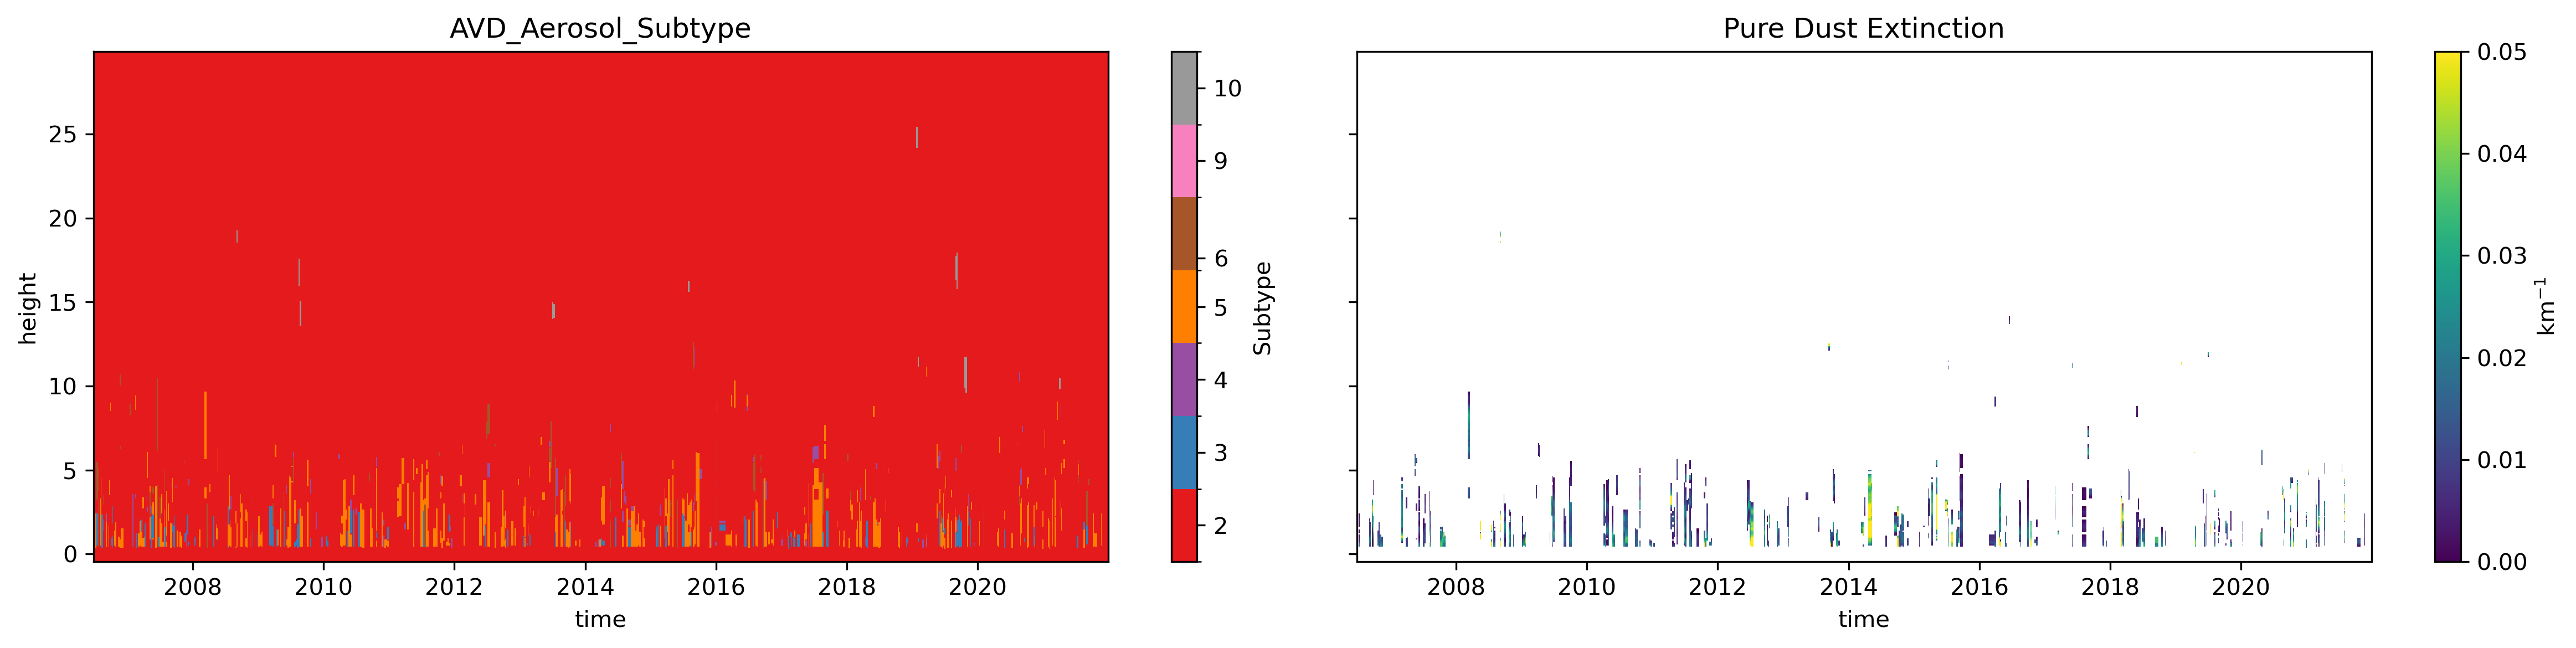

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.cm import get_cmap

x_dim, z_dim = "time", "height"

sub2 = ds["AVD_Aerosol_Subtype"].transpose(x_dim, z_dim).values
ext2 = (
    ds["Pure_Dust_Fine_Extinction_Coefficient_532"]
  + ds["Pure_Dust_Coarse_Extinction_Coefficient_532"]
).transpose(x_dim, z_dim).values
ext2m = np.ma.masked_where(ext2 <= 0, ext2)
x, y = ds["time"].values, ds["height"].values

subs = np.unique(sub2[sub2 > 0])
cmap = ListedColormap(get_cmap("Set1", len(subs)).colors)
norm = BoundaryNorm(np.r_[subs - 0.5, subs[-1] + 0.5], cmap.N)

fig, ax = plt.subplots(1, 2, figsize=(16, 4), sharey=True, dpi=300)

pcm0 = ax[0].pcolormesh(x, y, sub2.T, cmap=cmap, norm=norm, shading="nearest")
ax[0].set_title("AVD_Aerosol_Subtype")
ax[0].set_xlabel("time")
ax[0].set_ylabel("height")
fig.colorbar(pcm0, ax=ax[0], ticks=subs, label="Subtype")

pcm1 = ax[1].pcolormesh(x, y, ext2m.T, shading="auto",
                        cmap="viridis", vmin=0, vmax=0.05)
ax[1].set_title("Pure Dust Extinction")
ax[1].set_xlabel("time")
fig.colorbar(pcm1, ax=ax[1], label="km$^{-1}$")

plt.tight_layout()
plt.show()


In [14]:
subs = np.unique(sub2[sub2 > 0])
tot  = np.nansum(ext2[sub2 > 0])

for s in subs:
    frac = np.nansum(ext2[sub2 == s]) / tot
    print(f"Subtype {int(s)}: {frac:.2%}")

Subtype 2: 34.32%
Subtype 3: 0.00%
Subtype 4: 0.00%
Subtype 5: 65.61%
Subtype 6: 0.00%
Subtype 9: 0.00%
Subtype 10: 0.07%


In [15]:
subs = np.unique(sub2[sub2 > 0])
tot  = np.nansum(ext2m[sub2 > 0])

for s in subs:
    frac = np.nansum(ext2m[sub2 == s]) / tot
    print(f"Subtype {int(s)}: {frac:.2%}")

Subtype 2: 34.32%
Subtype 3: 0.00%
Subtype 4: 0.00%
Subtype 5: 65.61%
Subtype 6: 0.00%
Subtype 9: 0.00%
Subtype 10: 0.07%


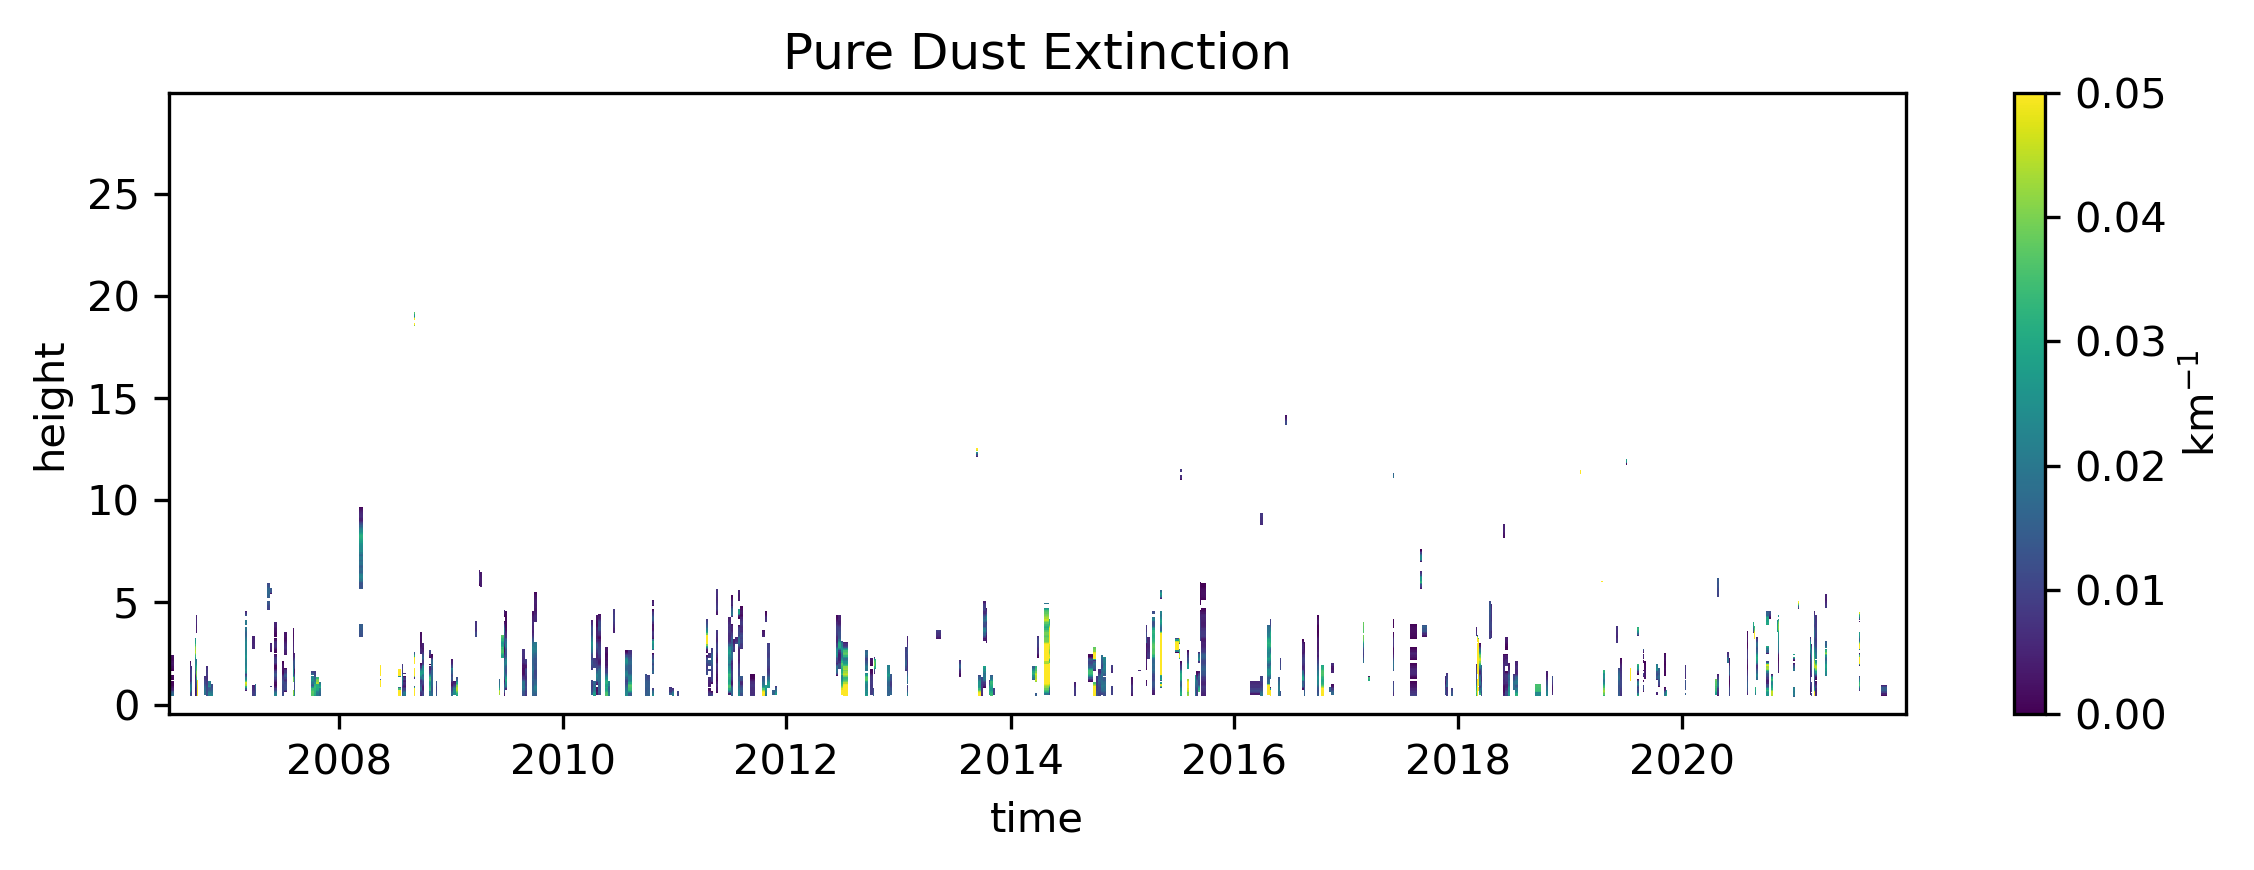

In [19]:
import numpy as np
import matplotlib.pyplot as plt

x_dim, z_dim = "time", "height"

# dust extinction（fine + coarse）
ext2 = (
    ds["Pure_Dust_Fine_Extinction_Coefficient_532"]
  + ds["Pure_Dust_Coarse_Extinction_Coefficient_532"]
).transpose(x_dim, z_dim).values

# 只保留 ext > 0
ext2m = np.ma.masked_where(ext2 <= 0, ext2)

x = ds["time"].values
y = ds["height"].values

fig, ax = plt.subplots(figsize=(8, 3), dpi=300)

pcm = ax.pcolormesh(
    x, y, ext2m.T,
    shading="auto",
    cmap="viridis",
    vmin=0,
    vmax=0.05
)

ax.set_title("Pure Dust Extinction")
ax.set_xlabel("time")
ax.set_ylabel("height")

cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label("km$^{-1}$")

plt.tight_layout()
plt.show()
